In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
data=pd.read_csv("accepted_2007_to_2018Q4.csv")

/var/folders/b0/w8bqz_dj3kz9p6j_f772qdpc0000gn/T/ipykernel_14441/722058391.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("accepted_2007_to_2018Q4.csv")


Let's create the binary viable "Bad loan" we have to predict. 

In [4]:
data["loan_status"].unique()
data["BadLoan"] = data["loan_status"].isin(["Charged Off", "Default", "In Grade Period", "Late (31-120 days)", "Late (16-30 days)"])
print((data["BadLoan"].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

BadLoan
False    86.98%
True     13.02%
Name: proportion, dtype: str


/var/folders/b0/w8bqz_dj3kz9p6j_f772qdpc0000gn/T/ipykernel_14441/2061752015.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["BadLoan"] = data["loan_status"].isin(["Charged Off", "Default", "In Grade Period", "Late (31-120 days)", "Late (16-30 days)"])


In [5]:
# Run models
import pandas as pd

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, roc_curve

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# optional
# pip install xgboost
from xgboost import XGBClassifier



# Features


features = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "installment",
    "revol_util",
    "total_acc",
    "open_acc"
]

target = "BadLoan"

X = data[features]
y = data[target]



# Missing NA


X = X.fillna(0)



# Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# Define models


models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(max_depth=6),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            eval_metric="logloss"
        )
}

# Train & evaluate

results = []
confusion_matrices = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:,1]

    pred = model.predict(X_test)

    auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    cm = confusion_matrix(y_test, pred)

    print("\n", name)
    print("AUC:", round(auc,3))
    print("PR-AUC:", round(pr_auc,3))
    print("Accuracy:", round(accuracy,3))
    print("Precision:", round(precision,3))
    print("Recall:", round(recall,3))
    print("F1 Score:", round(f1,3))
    print("Confusion matrix:")
    print(cm)

    results.append([name, auc, pr_auc, accuracy, precision, recall, f1])
    confusion_matrices[name] = cm

# 6. Compare results

results_df = pd.DataFrame(results, columns=["Model", "AUC", "PR-AUC", "Accuracy", "Precision", "Recall", "F1"])

print("\nModel comparison:")
print(results_df.sort_values("AUC", ascending=False))

# Save model
import joblib

joblib.dump(model, "model.pkl")

/Users/kellianvandaul/Library/Mobile Documents/com~apple~CloudDocs/Data Analysis/Lending Club Credit Risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Logistic Regression
AUC: 0.685
Confusion matrix:
[[392834    424]
 [ 58682    201]]

 Decision Tree
AUC: 0.697
Confusion matrix:
[[393257      1]
 [ 58883      0]]

 Random Forest
AUC: 0.698
Confusion matrix:
[[393258      0]
 [ 58883      0]]

 Gradient Boosting
AUC: 0.704
Confusion matrix:
[[393258      0]
 [ 58883      0]]

 XGBoost
AUC: 0.724
Confusion matrix:
[[393250      8]
 [ 58873     10]]

Model comparison:
                 Model       AUC
4              XGBoost  0.723744
3    Gradient Boosting  0.704023
2        Random Forest  0.697513
1        Decision Tree  0.697388
0  Logistic Regression  0.684977


['model.pkl']

# Results
## ROC & AUC charts

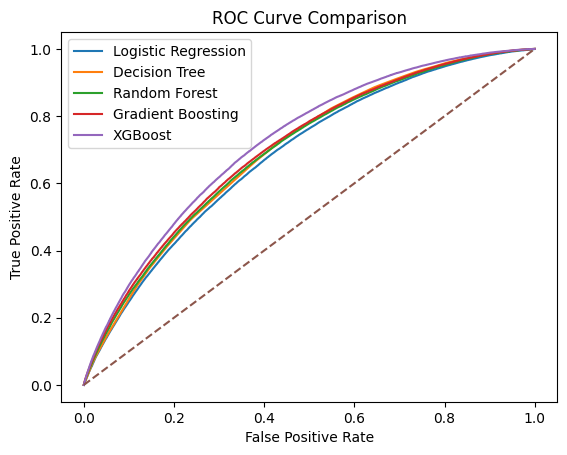

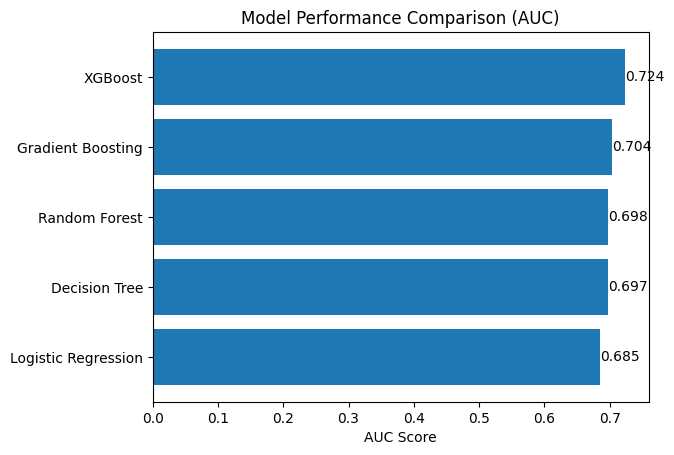

In [12]:
import matplotlib.pyplot as plt

plt.figure()

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("images/ROC_comparison.svg")
plt.show()

results_df = results_df.sort_values("AUC", ascending=True)

plt.figure()

plt.barh(results_df["Model"], results_df["AUC"])

plt.xlabel("AUC Score")
plt.title("Model Performance Comparison (AUC)")

for i, v in enumerate(results_df["AUC"]):
    plt.text(v, i, f"{v:.3f}", va="center")
plt.savefig("images/AUC_comparison.svg")
plt.show()

metric_columns = ["Accuracy", "Precision", "Recall", "F1", "AUC", "PR-AUC"]
metrics_heatmap_df = results_df.set_index("Model")[metric_columns]

plt.figure(figsize=(10, 4))
sns.heatmap(metrics_heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Model Metrics Heatmap")
plt.tight_layout()
plt.savefig("images/Metrics_heatmap.svg")
plt.show()

fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(18, 4))

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("images/Confusion_matrices.svg")
plt.show()
